# Сравнение OCR-движков для русских чеков

Этот ноутбук отвечает на практический вопрос: каким движком распознавать текст
на русских кассовых чеках. Исходная проблема — OCR в пайплайне читал кириллицу
плохо, и поля извлекались из мусора. Здесь мы сравниваем доступные локальные
движки на одном и том же реальном чеке и приходим к рабочему решению.

Сравниваем:

- **PaddleOCR** с моделью `lang="en"` и `lang="ru"`;
- **EasyOCR** с языками `ru+en`;
- **Surya** — OCR на трансформерах.

В конце проверяем отдельный, более надёжный путь для даты и суммы —
**фискальный QR-код** чека.

Тест честный: один и тот же чек, один и тот же вход (без бинаризации), смотрим
и на качество кириллицы, и на числа.

Техническая деталь: каждый движок запускается в отдельном процессе. PaddlePaddle
и PyTorch (его используют EasyOCR и Surya) на Windows конфликтуют по DLL внутри
одного процесса, поэтому изоляция в подпроцессах — самый надёжный способ
прогнать их в одном ноутбуке.

## Запуск в Google Colab

Ячейка ниже готовит проект к запуску в Colab по кнопке **Run all** без
ручных действий: код клонируется из GitHub, ставятся OCR-движки (EasyOCR,
Surya и, по возможности, PaddleOCR). Тестовый чек и веса Surya уже лежат в
репозитории — скачивать ничего не нужно.

PaddleOCR ставится отдельным шагом и «по возможности»: на свежих версиях
Python в Colab колёс для него может не быть. Если движок не установился или
не запустился, ноутбук **не падает** — этот движок просто помечается как N/A
в итоговой таблице, а сравнение остальных проходит до конца.

In [ ]:
# === Подготовка окружения для Colab (код из GitHub, движки через pip) ===
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# Публичный git-репозиторий с кодом проекта.
REPO_URL = "https://github.com/ScarletFlame611/Receipt-AI.git"


def _find_project_root():
    """Каталог, где есть src/. Тестовый чек и веса Surya уже в репозитории."""
    here = Path.cwd()
    if (here / "src").is_dir():
        return here
    for sub in sorted(pp for pp in here.iterdir() if pp.is_dir()):
        if (sub / "src").is_dir():
            return sub
    return None


if IN_COLAB:
    # EasyOCR и Surya ставятся надёжно — отдельным вызовом.
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "easyocr", "surya-ocr==0.13.1", "opencv-python-headless"],
        check=False,
    )
    # PaddleOCR — отдельным шагом: при несовместимости с версией Python в
    # Colab установка может упасть, и это не должно прерывать ноутбук.
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "paddlepaddle==2.6.2", "paddleocr==2.9.1"],
        check=False,
    )
    if _find_project_root() is None and "USER/" not in REPO_URL:
        subprocess.run(["git", "clone", REPO_URL], check=True)

for _m in [m for m in sys.modules if m == "src" or m.startswith("src.")]:
    del sys.modules[_m]

root = _find_project_root()
if root is None:
    raise RuntimeError(
        "Не найден корень проекта (папка src/). В Colab проверьте клонирование "
        "(или поле REPO_URL) и перезапустите ячейку."
    )
os.chdir(root)
sys.path.insert(0, str(root))
print("Colab:", IN_COLAB, "| корень проекта:", root)

## Тестовый чек

Берём реальную фотографию `1chek_1045.jpg` — выцветший термочек магазина
«Магнит». Это трудный вход: низкий контраст, лёгкий перекос, мелкий шрифт — ровно
тот случай, на котором классический OCR и спотыкается.

изображение: (740, 400, 3) | файл: 1chek_1045.jpg


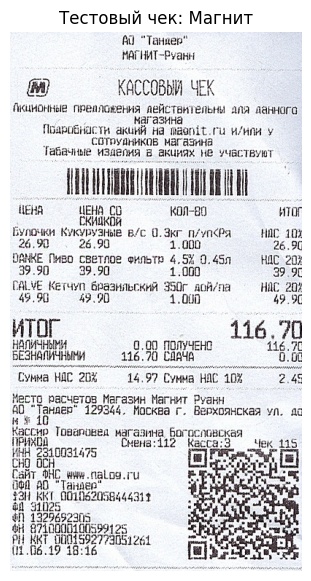

In [1]:
import sys, json, subprocess, statistics, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

import cv2
import pandas as pd
import matplotlib.pyplot as plt

img_path = root / "1chek_1045.jpg"
img = cv2.imread(str(img_path))
print("изображение:", img.shape, "| файл:", img_path.name)

plt.figure(figsize=(4, 7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Тестовый чек: Магнит")
plt.show()

## Эталон (что на чеке)

Чтобы судить о качестве распознавания, зафиксируем, что реально напечатано на
чеке:

- **магазин:** АО «Тандер» / МАГНИТ;
- **товары:** Булочки кукурузные — 26.90; DANKE Пиво светлое — 39.90;
  CALVE Кетчуп бразильский — 49.90;
- **итог:** 116.70;
- **дата:** 01.06.19 18:16.

Дальше каждый движок сравниваем с этим эталоном.

## Вспомогательные функции

`run_engine` запускает переданный код движка в отдельном интерпретаторе. Обмен
идёт через файл: подпроцесс пишет результат (список пар «текст, уверенность») в
JSON по пути из переменной окружения `ENGINE_OUT`, а ядро ноутбука его читает.
Файловый обмен надёжнее разбора stdout — на него не влияют прогресс-бары и
служебные логи движков. `show` печатает первые строки распознавания, а две
метрики (средняя уверенность и доля кириллицы) дают числовую сводку: для
русского чека высокая доля кириллицы означает, что движок реально прочитал
буквы, а не подобрал латинские похожие.

In [2]:
import os

def run_engine(body, tag):
    """Выполняет body движка в отдельном процессе; результат читает из файла."""
    out_path = root / f"_engine_{tag}.json"
    if out_path.exists():
        out_path.unlink()
    # OMP_NUM_THREADS=1 и KMP_DUPLICATE_LIB_OK снимают конфликт OpenMP-рантаймов
    # torch на Windows CPU (иначе тяжёлые движки иногда падают с access violation).
    env = dict(os.environ, PYTHONUTF8="1", PYTHONIOENCODING="utf-8",
               ENGINE_OUT=str(out_path),
               OMP_NUM_THREADS="1", KMP_DUPLICATE_LIB_OK="TRUE")
    proc = subprocess.run(
        [sys.executable, "-c", body],
        capture_output=True, text=True, encoding="utf-8", cwd=str(root), env=env,
    )
    if not out_path.exists():
        tail = (proc.stderr or "").strip().splitlines()
        print(f"[warn] движок {tag} недоступен (код {proc.returncode}); "
              f"в сравнении помечен как N/A.")
        if tail:
            print("   ", tail[-1][:200])
        return []
    try:
        data = json.loads(out_path.read_text(encoding="utf-8"))
    except Exception:
        out_path.unlink(missing_ok=True)
        print(f"[warn] движок {tag}: некорректный вывод; помечен как N/A.")
        return []
    out_path.unlink()
    return [(t, float(c)) for t, c in data]

def show(lines, n=14):
    for text, conf in lines[:n]:
        print(f"{conf:.2f}  {text}")
    if len(lines) > n:
        print(f"... ещё {len(lines) - n} строк")

def mean_conf(lines):
    return round(statistics.mean([c for _, c in lines]), 2) if lines else 0.0

def cyrillic_ratio(lines):
    text = "".join(t for t, _ in lines)
    letters = [ch for ch in text if ch.isalpha()]
    if not letters:
        return 0.0
    cyr = sum("а" <= ch.lower() <= "я" or ch.lower() == "ё" for ch in letters)
    return round(cyr / len(letters), 2)

## PaddleOCR: английская и русская модели

PaddleOCR в проекте изначально вызывался с `lang="en"`. Проверяем обе модели.
Английская использует латинский словарь распознавания — кириллицу она в принципе
выдать не может, только похожие латинские символы. Русская модель должна быть
точнее на буквах. Смотрим, так ли это.

In [3]:
PADDLE = """
import os, json, cv2
from paddleocr import PaddleOCR
img = cv2.imread("1chek_1045.jpg")
raw = PaddleOCR(use_angle_cls=True, lang="{lang}", show_log=False).ocr(img, cls=True)
rows = raw[0] if raw and raw[0] else []
out = [[t, float(c)] for _b, (t, c) in rows]
json.dump(out, open(os.environ["ENGINE_OUT"], "w", encoding="utf-8"), ensure_ascii=False)
"""

paddle_en = run_engine(PADDLE.format(lang="en"), "paddle_en")
paddle_ru = run_engine(PADDLE.format(lang="ru"), "paddle_ru")

print("=== PaddleOCR lang=en ===")
show(paddle_en)
print("\n=== PaddleOCR lang=ru ===")
show(paddle_ru)

=== PaddleOCR lang=en ===
0.83  ATaHnep
0.84  MAIHMT-PyaHH
0.93  M
0.93  KACCOBbM 4EK
0.59  HoHe npeneHH AecTBnTenbH An aHHoro
0.74  noapoicrn akunn Ha maonit.ru n/nnn y
0.70  Mara3uHa
0.75  COTpyaHHKOB MarasnHa
0.67  Ta6ae n3Aenng B akunx He yyacTBy
0.89  HEHA
0.92  EHA CO
0.81  KOn-80
0.66  HTO
0.71  CKNAKON
... ещё 47 строк

=== PaddleOCR lang=ru ===
0.67  Ht
0.83  Tандер
0.69  ћ.
0.68  Pyahh
0.74  KACCOBDU
0.57  Npt  aulehis
0.68  дEUETBHT
0.52  Etkhi
0.81  дагног
0.71  авина
0.57  аiигiй
0.62  Hй
0.72  tarit.
0.51  ћћи
... ещё 66 строк


Видно главное противоречие PaddleOCR на русском чеке. Английская модель даёт
связный результат и **точные числа** (26.90, 39.90, 116.70, дата), но кириллицу
отображает транслитом латиницей — для названий товаров это бесполезно. Русская
же модель PaddleOCR 2.x выдаёт мусор с низкой уверенностью: кириллический словарь
здесь работает плохо. Вывод: PaddleOCR не подходит для извлечения русского
текста.

## EasyOCR: ru + en

EasyOCR — нейросетевой движок с отдельной поддержкой кириллицы. Подаём цветное
изображение без бинаризации (модели обучены на естественных фото).

In [4]:
EASY = """
import os, json, cv2, easyocr
img = cv2.imread("1chek_1045.jpg")
reader = easyocr.Reader(["ru", "en"], gpu=False)
res = reader.readtext(img, detail=1, paragraph=False)
out = [[t, float(c)] for _b, t, c in res]
json.dump(out, open(os.environ["ENGINE_OUT"], "w", encoding="utf-8"), ensure_ascii=False)
"""

easy = run_engine(EASY, "easyocr")
print("=== EasyOCR ru+en ===")
show(easy)

=== EasyOCR ru+en ===
0.22  Hi)
0.50  ТаННдер
0.27  МНГМИТ-Ёчанн
0.86  КАССОВЫ ЧЕК
0.10  пцнUHныe преплакення ЛёЙЕТЫнтёльны
0.59  АПЯ даННUГО
0.43  НЯi азнна
0.08  {luдptGiar:тн   ditHЙ Hа Iizgnit /i Н:нпи
0.48  СПТОУДННКПБ Нагаз На
0.10  Tafin INЫЁ ИЗДЕЛИЯ ₽ акчнях HE YЧGLТВУЮТ
0.47  IlE}Я
0.03  ЦRHКЕq
0.36  KUЛ-BUJ
0.13  [УfО:IКИ КУКУС}ЗНЫЕ E/c 1. Зкг пчпфря
... ещё 49 строк


EasyOCR заметно лучше PaddleOCR по кириллице: читаются «КАССОВЫЙ ЧЕК»,
«Чек», узнаётся структура. Но текст всё ещё грязный, а числовые столбцы (цены)
рвутся. Это ближе к рабочему, но недостаточно надёжно.

## Surya

Surya — OCR на трансформерах с детекцией строк и распознаванием. Запускаем тот
самый класс `OCREngine` из пайплайна (он обёрнут вокруг Surya), чтобы проверять
ровно то, что работает в продукте. Первый запуск догружает веса модели, поэтому
эта ячейка считается дольше других.

In [5]:
SURYA = """
import os, sys, json, cv2
sys.path.insert(0, ".")
from src.models.ocr import OCREngine
img = cv2.imread("1chek_1045.jpg")
lines = OCREngine().recognize(img)
out = [[l["text"], float(l["confidence"])] for l in lines]
json.dump(out, open(os.environ["ENGINE_OUT"], "w", encoding="utf-8"), ensure_ascii=False)
"""

surya = run_engine(SURYA, "surya")
print("=== Surya ru+en ===")
show(surya)

=== Surya ru+en ===
0.69  АП "Тандер
0.68  МАГНИТ-Руанн
0.81  КАССОВЫЙ ЧЕК
0.33  вый!
0.93  пкционные предложения действительны аля данного
0.59  нагазина
0.88  Подробности акций на тавното ги илипи у
0.77  СОТРУДНИКОВ Нагазина
0.96  Габачные изделия в акциях не участвуют
0.46  ПЕНА
0.63  ЦЕНА СО
0.59  кол-во
0.31  итель
0.57  скидкой
... ещё 47 строк


Surya читает русский текст по-настоящему: магазин «МАГНИТ», названия товаров
(БУЛОЧКИ КУКУРУЗНЫЕ, DANKE Пиво, CALVE Кетчуп), адрес, ИНН, кассир, дата —
дословно или почти. Именно такой чистый текст и нужен на вход NER и
категоризатору. Слабое место — узкая колонка цен, где числа местами искажаются;
этот пробел закроем QR-кодом ниже.

## Сводное сравнение

Сводим движки в одну таблицу по простым числовым признакам: число найденных
строк, средняя уверенность и доля кириллицы среди распознанных букв. Для
русского чека ключевой показатель — доля кириллицы: он отделяет движки, которые
реально читают буквы, от тех, что подбирают латиницу.

In [6]:
summary = pd.DataFrame([
    {"движок": "PaddleOCR en", "строк": len(paddle_en),
     "ср. conf": mean_conf(paddle_en), "доля кириллицы": cyrillic_ratio(paddle_en)},
    {"движок": "PaddleOCR ru", "строк": len(paddle_ru),
     "ср. conf": mean_conf(paddle_ru), "доля кириллицы": cyrillic_ratio(paddle_ru)},
    {"движок": "EasyOCR ru+en", "строк": len(easy),
     "ср. conf": mean_conf(easy), "доля кириллицы": cyrillic_ratio(easy)},
    {"движок": "Surya ru+en", "строк": len(surya),
     "ср. conf": mean_conf(surya), "доля кириллицы": cyrillic_ratio(surya)},
])
print(summary.to_string(index=False))

       движок  строк  ср. conf  доля кириллицы
 PaddleOCR en     61      0.86            0.00
 PaddleOCR ru     80      0.68            0.33
EasyOCR ru+en     63      0.43            0.69
  Surya ru+en     61      0.66            0.93


Таблица подтверждает вывод по распечаткам выше. PaddleOCR en даёт высокую
уверенность, но низкую долю кириллицы (буквы — латиницей). PaddleOCR ru читает
кириллицу формально, но с низкой уверенностью и мусором. EasyOCR и Surya дают
высокую долю кириллицы, и на глаз Surya чище по словам и реквизитам. Для русских
чеков выбираем **Surya**.

## Фискальный QR-код: точные дата и сумма

Текст — это ещё не всё. Слабое место всех OCR на этом чеке — числа в узких
колонках. Но российский чек несёт **фискальный QR-код**, где дата и итоговая
сумма закодированы в явном виде:

```
t=ГГГГММДДTЧЧММ & s=СУММА & fn=... & i=... & fp=... & n=...
```

Декодируем штатным `cv2.QRCodeDetector` — без системных зависимостей и устойчиво
к повороту. Это даёт дату и сумму детерминированно и точно, минуя ошибки OCR.

In [7]:
sys.path.insert(0, str(root))
from src.models.qr_extractor import parse_payload

detector = cv2.QRCodeDetector()
payload, points, _ = detector.detectAndDecode(img)
print("QR payload:", payload)

parsed = parse_payload(payload)
print("\nразобранные поля:")
for k, v in parsed.items():
    print(f"  {k:6s} = {v}")

QR payload: t=20190601T1816&s=116.70&fn=8710000100599125&i=31025&fp=1329692305&n=1

разобранные поля:
  date   = 2019-06-01
  time   = 18:16
  total  = 116.70
  fn     = 8710000100599125
  i      = 31025
  fp     = 1329692305
  n      = 1
  raw    = t=20190601T1816&s=116.70&fn=8710000100599125&i=31025&fp=1329692305&n=1


QR декодировался с первого раза и дал **точные** дату (2019-06-01) и сумму
(116.70) — ровно те поля, где OCR ошибался. Плюс фискальные реквизиты `fn/i/fp`,
по которым при необходимости можно запросить полный чек у ОФД.

Замечание про альтернативу: пробовали `pyzbar` (zbar) — на Windows он не
загружается без системного VC++ Redistributable, тогда как `cv2.QRCodeDetector`
работает из коробки. Поэтому в пайплайне используем OpenCV.

## Итог

- **PaddleOCR** (любой язык) для русских чеков не годится: либо латиница вместо
  кириллицы, либо мусор.
- **EasyOCR** читает кириллицу, но недостаточно чисто.
- **Surya** — лучший локальный OCR для текста русского чека: магазин, товары,
  реквизиты читаются дословно. Цена — медленнее на CPU.
- **Числа (дата, сумма)** надёжнее всего брать из **фискального QR-кода**, а не
  из OCR.

Итоговая архитектура распознавания: **Surya** извлекает текст (магазин, позиции,
бренды), а **QR-код** даёт точные дату и сумму; регулярные выражения по тексту
OCR остаются запасным путём, когда QR нечитаем. Именно так и собран пайплайн.